In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import math


## RNN code

In [ ]:
class MDRNN(nn.Module):
    """Mixture Density RNN for CartPole world model.
    
    Predicts next state distribution as a Gaussian Mixture Model.
    State: [x, x_dot, theta, theta_dot] (4D)
    Action: one-hot encoded discrete action (2D for CartPole: [1,0] or [0,1])
    """
    
    def __init__(self, state_dim=4, action_dim=2, hidden_dim=256, 
                 n_gaussian=5, n_layers=1):
        super().__init__()
        
        self.state_dim = state_dim
        self.action_dim = action_dim
        self.hidden_dim = hidden_dim
        self.n_gaussian = n_gaussian
        self.n_layers = n_layers
        
        # LSTM that processes state+action sequences
        self.lstm = nn.LSTM(
            state_dim + action_dim, 
            hidden_dim, 
            n_layers, 
            batch_first=True
        )
        
        # Output heads for mixture density network
        self.pi_head = nn.Linear(hidden_dim, n_gaussian)
        self.mu_head = nn.Linear(hidden_dim, n_gaussian * state_dim)
        self.sigma_head = nn.Linear(hidden_dim, n_gaussian * state_dim)
        
    def forward(self, states, actions, hidden=None):
        """
        Args:
            states: (batch, seq_len, state_dim)
            actions: (batch, seq_len, action_dim)
            hidden: tuple of (h, c) for LSTM hidden states
        
        Returns:
            dict with:
                pi: mixture weights (batch, seq_len, n_gaussian)
                mu: means (batch, seq_len, n_gaussian, state_dim)
                sigma: std devs (batch, seq_len, n_gaussian, state_dim)
                hidden: updated LSTM hidden state
        """
        batch_size, seq_len = states.shape[:2]
        
        # Concatenate state and action
        x = torch.cat([states, actions], dim=-1)
        
        # Process through LSTM
        lstm_out, hidden = self.lstm(x, hidden)
        
        # Compute mixture parameters
        pi = self.pi_head(lstm_out).view(batch_size, seq_len, self.n_gaussian)
        mu = self.mu_head(lstm_out).view(batch_size, seq_len, self.n_gaussian, self.state_dim)
        sigma = self.sigma_head(lstm_out).view(batch_size, seq_len, self.n_gaussian, self.state_dim)
        
        # Apply activations
        pi = F.softmax(pi, dim=-1)  # Normalize mixture weights
        sigma = F.softplus(sigma) + 0.01  # Ensure positive std dev with reasonable minimum
        
        return {
            'pi': pi,
            'mu': mu, 
            'sigma': sigma,
            'hidden': hidden
        }
    
    def sample_prediction(self, pi, mu, sigma, temperature=1.0):
        """Sample next state from the mixture distribution.
        
        Args:
            pi: (n_gaussian,) - mixture weights
            mu: (n_gaussian, state_dim) - means
            sigma: (n_gaussian, state_dim) - std devs
            temperature: sampling temperature (higher = more random)
        
        Returns:
            next_state: (state_dim,) - sampled next state
        """
        # Apply temperature to mixture weights
        if temperature != 1.0:
            pi = F.softmax(torch.log(pi + 1e-8) / temperature, dim=-1)
        
        # Sample mixture component
        k = torch.multinomial(pi, 1).item()
        
        # Sample from the selected gaussian
        mean = mu[k]
        std = sigma[k] * temperature
        next_state = torch.normal(mean, std)
        
        return next_state
    
    def predict_next_state(self, state, action, hidden=None, temperature=1.0, deterministic=False):
        """Predict next state given current state and action.
        
        Args:
            state: (state_dim,) numpy array or tensor
            action: int (discrete action) or (action_dim,) one-hot array
            hidden: LSTM hidden state, or None to create new
            temperature: sampling temperature
            deterministic: if True, return mean of highest-weight mixture component
        
        Returns:
            next_state: (state_dim,) predicted next state
            hidden: updated hidden state
        """
        device = next(self.parameters()).device
        
        # Convert inputs to tensors
        if isinstance(state, np.ndarray):
            state = torch.from_numpy(state).float()
        if isinstance(action, int):
            # Convert discrete action to one-hot
            action_onehot = torch.zeros(self.action_dim)
            action_onehot[action] = 1.0
            action = action_onehot
        elif isinstance(action, np.ndarray):
            action = torch.from_numpy(action).float()
        
        # Add batch and sequence dimensions: (1, 1, dim)
        state = state.unsqueeze(0).unsqueeze(0).to(device)
        action = action.unsqueeze(0).unsqueeze(0).to(device)
        
        # Initialize hidden if needed
        if hidden is None:
            hidden = self.init_hidden(1, device)
        
        # Forward pass
        with torch.no_grad():
            outputs = self(state, action, hidden)
        
        # Get predictions for single timestep
        pi = outputs['pi'][0, 0]      # (n_gaussian,)
        mu = outputs['mu'][0, 0]      # (n_gaussian, state_dim)
        sigma = outputs['sigma'][0, 0]  # (n_gaussian, state_dim)
        
        if deterministic:
            # Return mean of highest-weight component
            k = pi.argmax()
            next_state = mu[k].cpu().numpy()
        else:
            # Sample from mixture
            next_state = self.sample_prediction(pi, mu, sigma, temperature).cpu().numpy()
        
        return next_state, outputs['hidden']
    
    def init_hidden(self, batch_size, device):
        """Initialize LSTM hidden state."""
        h = torch.zeros(self.n_layers, batch_size, self.hidden_dim, device=device)
        c = torch.zeros(self.n_layers, batch_size, self.hidden_dim, device=device)
        return (h, c)


def mdn_loss(pi, mu, sigma, target, reduce=True):
    """Negative log-likelihood loss for mixture density network.
    
    Args:
        pi: (batch, seq_len, n_gaussian)
        mu: (batch, seq_len, n_gaussian, state_dim)
        sigma: (batch, seq_len, n_gaussian, state_dim)
        target: (batch, seq_len, state_dim) - actual next states
    
    Returns:
        loss: scalar or (batch, seq_len) depending on reduce
    """
    # Expand target for broadcasting
    target = target.unsqueeze(2)  # (batch, seq_len, 1, state_dim)
    
    # Compute gaussian probabilities
    variance = sigma ** 2
    log_prob = -0.5 * ((target - mu) ** 2) / variance
    log_prob = log_prob - 0.5 * torch.log(2 * math.pi * variance)
    
    # Sum over state dimensions
    log_prob = log_prob.sum(dim=-1)  # (batch, seq_len, n_gaussian)
    
    # Weight by mixture coefficients
    weighted_log_prob = log_prob + torch.log(pi + 1e-8)
    
    # LogSumExp for numerical stability
    max_log_prob = weighted_log_prob.max(dim=-1, keepdim=True)[0]
    log_sum_exp = max_log_prob + torch.log(torch.exp(weighted_log_prob - max_log_prob).sum(dim=-1, keepdim=True))
    
    nll = -log_sum_exp.squeeze(-1)
    
    if reduce:
        return nll.mean()
    return nll

def plot_training_losses(state_losses, total_episodes=None, steps_per_batch=None, 
                         checkpoint_iterations=None):
    """Plot training losses over total steps experienced.
    
    Args:
        state_losses: State prediction loss array
        total_episodes: Total episodes experienced (optional)
        steps_per_batch: Steps per training iteration (optional)
        checkpoint_iterations: List of iteration numbers where checkpoints were saved (optional)
    """
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
    
    # X-axis is now total steps, not iterations
    if steps_per_batch is not None:
        # Each iteration corresponds to steps_per_batch steps
        # X values: steps_per_batch, 2*steps_per_batch, 3*steps_per_batch, ...
        x_values = [(i + 1) * steps_per_batch for i in range(len(state_losses))]
        total_steps = len(state_losses) * steps_per_batch
        x_label = 'Total Steps Experienced'
    else:
        # Fallback to iterations if steps_per_batch not provided
        x_values = range(len(state_losses))
        total_steps = len(state_losses)
        x_label = 'Training Iteration'
    
    # Add informative title
    title = f'Training Losses ({len(state_losses)} iterations'
    if total_episodes is not None:
        title += f', {total_episodes} episodes'
    if steps_per_batch is not None:
        title += f', {total_steps:,} total steps'
    title += ')'
    fig.suptitle(title, fontsize=14, y=1.02)
    
    # Helper function to add checkpoint lines
    def add_checkpoint_lines(ax):
        if checkpoint_iterations is not None and steps_per_batch is not None:
            for i, checkpoint_iter in enumerate(checkpoint_iterations, 1):
                # Convert iteration to steps
                checkpoint_step = checkpoint_iter * steps_per_batch
                ax.axvline(x=checkpoint_step, color='red', linestyle='--', 
                          alpha=0.6, linewidth=1.5, label=f'Checkpoint {i}' if i == 1 else '')
    
    # Plot 1: State loss with raw and smoothed
    ax1.plot(x_values, state_losses, 'g-', alpha=0.5, label='Raw Loss', linewidth=1)
    ax1.set_title('State Prediction Loss (MDN)')
    ax1.set_xlabel(x_label)
    ax1.set_ylabel('Negative Log-Likelihood Loss')
    ax1.grid(True, alpha=0.3)
    
    # Add smoothed line for state loss
    if len(state_losses) > 50:
        window = min(100, len(state_losses) // 10)
        smoothed = np.convolve(state_losses, np.ones(window)/window, mode='valid')
        smoothed_x = x_values[window-1:]
        ax1.plot(smoothed_x, smoothed, 'darkgreen', linewidth=2.5, label='Smoothed')
    
    add_checkpoint_lines(ax1)
    ax1.legend()
    
    # Plot 2: Loss distribution (histogram)
    ax2.hist(state_losses, bins=50, alpha=0.7, color='green', edgecolor='black')
    ax2.axvline(x=np.mean(state_losses), color='red', linestyle='--', 
               linewidth=2, label=f'Mean: {np.mean(state_losses):.4f}')
    ax2.axvline(x=np.median(state_losses), color='orange', linestyle='--', 
               linewidth=2, label=f'Median: {np.median(state_losses):.4f}')
    ax2.set_title('Loss Distribution')
    ax2.set_xlabel('State Prediction Loss')
    ax2.set_ylabel('Frequency')
    ax2.grid(True, alpha=0.3)
    ax2.legend()
    
    plt.tight_layout()
    plt.show()
    
    # Print final statistics
    print(f"\n{'='*60}")
    print(f"Training Statistics:")
    print(f"  Total iterations: {len(state_losses)}")
    if total_episodes is not None:
        print(f"  Total episodes: {total_episodes}")
    if steps_per_batch is not None:
        print(f"  Steps per batch: {steps_per_batch}")
        print(f"  Total steps: {total_steps:,}")
    if checkpoint_iterations is not None and steps_per_batch is not None:
        checkpoint_steps = [it * steps_per_batch for it in checkpoint_iterations]
        print(f"  Checkpoints saved at steps: {checkpoint_steps}")
    print(f"\nFinal Loss:")
    print(f"  State Loss: {state_losses[-1]:.4f}")
    print(f"\nLoss Statistics:")
    print(f"  Mean: {np.mean(state_losses):.4f}")
    print(f"  Median: {np.median(state_losses):.4f}")
    print(f"  Std Dev: {np.std(state_losses):.4f}")
    print(f"  Min: {np.min(state_losses):.4f}")
    print(f"  Max: {np.max(state_losses):.4f}")
    
    # Show improvement
    if len(state_losses) > 100:
        initial_avg = np.mean(state_losses[:100])
        final_avg = np.mean(state_losses[-100:])
        improvement = ((initial_avg - final_avg) / initial_avg) * 100
        print(f"\nImprovement:")
        print(f"  Loss improvement: {improvement:.1f}% (from {initial_avg:.4f} to {final_avg:.4f})")
    print(f"{'='*60}")

def list_available_checkpoints(save_dir='../trained_models'):
    """List all available model checkpoints in a directory.
    
    Args:
        save_dir: Directory to search for model files
        
    Returns:
        List of checkpoint file paths
    """
    import os
    import glob
    
    # Try both naming conventions
    pattern_steps = os.path.join(save_dir, 'mdrnn_*_steps.pt')
    pattern_episodes = os.path.join(save_dir, 'mdrnn_*_episodes.pt')
    
    model_files = sorted(glob.glob(pattern_steps))
    if not model_files:
        model_files = sorted(glob.glob(pattern_episodes))
    
    if not model_files:
        print(f"No model files found in {save_dir}")
        return []
    
    print(f"Found {len(model_files)} checkpoints in {save_dir}:")
    for i, file_path in enumerate(model_files, 1):
        # Extract count from filename
        filename = os.path.basename(file_path)
        # Handle both "mdrnn_20000_steps.pt" and "mdrnn_1000_episodes.pt"
        parts = filename.split('_')
        count = parts[1]
        unit = parts[2].replace('.pt', '')  # 'steps' or 'episodes'
        print(f"  [{i}] {filename} ({count} {unit})")
    
    return model_files

def train_mdrnn(env, mdrnn, total_steps=100000, lr=1e-3, steps_per_batch=100, 
                save_dir='../trained_models'):
    """Train the MD-RNN on CartPole environment.
    
    Args:
        total_steps: Total environment steps to train on
        lr: Learning rate
        steps_per_batch: Number of steps per training iteration (collected across multiple episodes)
        save_dir: Directory to save model checkpoints
    """
    
    import os
    import numpy as np
    
    os.makedirs(save_dir, exist_ok=True)
    
    optimizer = torch.optim.Adam(mdrnn.parameters(), lr=lr)
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    mdrnn = mdrnn.to(device)
    
    # Calculate checkpoint steps (evenly distributed)
    checkpoint_steps = [total_steps // 5 * i for i in range(1, 6)]
    print(f"Will save models at steps: {checkpoint_steps}")
    print(f"Training with {steps_per_batch} steps per batch")
    print(f"Expected iterations: {total_steps // steps_per_batch}\n")
    
    # Track losses
    state_losses = []
    
    total_steps_experienced = 0
    total_episodes_experienced = 0
    training_iteration = 0
    checkpoints_saved = 0
    checkpoint_iterations = []
    
    # Randomization ranges
    angle_range = 0.18
    angular_vel_range = 2.0
    pos_range = 2.0
    vel_range = 2.0
    
    # Get action space size for one-hot encoding
    n_actions = env.action_space.n
    
    def reset_with_randomization():
        """Reset environment with randomized initial state."""
        env.unwrapped.tau = 0.01
        state, _ = env.reset()
        
        # Add randomness to initial state
        state[0] = np.random.uniform(-pos_range, pos_range)          
        state[1] = np.random.uniform(-vel_range, vel_range)         
        state[2] = np.random.uniform(-angle_range, angle_range)       
        state[3] = np.random.uniform(-angular_vel_range, angular_vel_range)
        
        # Update the environment's internal state
        env.unwrapped.state = state
        return state
    
    def action_to_onehot(action, n_actions):
        """Convert discrete action to one-hot encoding."""
        onehot = np.zeros(n_actions, dtype=np.float32)
        onehot[action] = 1.0
        return onehot
    
    
    while total_steps_experienced < total_steps:
        # Collect episodes until we have enough steps for this batch
        episodes = []  # List of (states, actions, next_states) tuples
        steps_collected = 0
        
        # Determine how many steps to collect (don't exceed total_steps)
        steps_to_collect = min(steps_per_batch, total_steps - total_steps_experienced)
        
        # Collect episodes
        while steps_collected < steps_to_collect:
            episode_states = []
            episode_actions = []
            episode_next_states = []
            
            done = False
            
            # Collect one complete episode (or until we reach steps_to_collect)
            while not done and steps_collected < steps_to_collect:

                # Sample random action
                action = env.action_space.sample()
                
                # Take step in environment
                next_state, reward, terminated, truncated, _ = env.step(action)
                done = terminated or truncated
                
                # Convert action to one-hot encoding
                action_onehot = action_to_onehot(action, n_actions)
                
                # Store transition
                episode_states.append(state)
                episode_actions.append(action_onehot)
                episode_next_states.append(next_state)
                
                # Update state
                state = next_state
                steps_collected += 1
                
            # Store this episode if it has any data
            if len(episode_states) > 0:
                episodes.append({
                    'states': np.array(episode_states, dtype=np.float32),
                    'actions': np.array(episode_actions, dtype=np.float32),
                    'next_states': np.array(episode_next_states, dtype=np.float32)
                })
                total_episodes_experienced += 1
            
            # Reset environment with randomization for next episode
            if done or steps_collected >= steps_to_collect:
                state = reset_with_randomization()
        
        # Update step counter
        total_steps_experienced += steps_collected
        
        # Skip if we collected no data (shouldn't happen, but safety check)
        if len(episodes) == 0:
            break
        
        # Train on collected episodes
        # Each episode gets its own hidden state that's reset at the start
        optimizer.zero_grad()
        total_loss = 0
        
        for episode in episodes:
            # Convert episode to tensors - shape: (1, episode_length, dim)
            states_t = torch.from_numpy(episode['states']).unsqueeze(0).to(device)
            actions_t = torch.from_numpy(episode['actions']).unsqueeze(0).to(device)
            next_states_t = torch.from_numpy(episode['next_states']).unsqueeze(0).to(device)
            
            # Reset hidden state for this episode
            hidden = mdrnn.init_hidden(1, device)
            
            # Forward pass
            outputs = mdrnn(states_t, actions_t, hidden)
            
            # Compute loss for this episode
            episode_loss = mdn_loss(outputs['pi'], outputs['mu'], outputs['sigma'], next_states_t)
            total_loss += episode_loss
        
        # Average loss across all episodes in this batch
        avg_loss = total_loss / len(episodes)
        
        # Store loss
        state_losses.append(avg_loss.item())
        
        # Backward pass
        avg_loss.backward()
        torch.nn.utils.clip_grad_norm_(mdrnn.parameters(), 10.0)
        optimizer.step()
        
        training_iteration += 1
        
        # Save model at checkpoints (based on steps)
        if checkpoints_saved < len(checkpoint_steps) and total_steps_experienced >= checkpoint_steps[checkpoints_saved]:
            checkpoint_path = os.path.join(save_dir, f'mdrnn_{total_steps_experienced}_steps.pt')
            torch.save({
                'state_dim': mdrnn.state_dim,
                'action_dim': mdrnn.action_dim,
                'hidden_dim': mdrnn.hidden_dim,
                'n_gaussian': mdrnn.n_gaussian,
                'n_layers': mdrnn.n_layers,
                'training_iteration': training_iteration,
                'total_steps_experienced': total_steps_experienced,
                'total_episodes_experienced': total_episodes_experienced,
                'model_state_dict': mdrnn.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'state_loss': avg_loss.item(),
            }, checkpoint_path)
            
            checkpoint_iterations.append(training_iteration)
            checkpoints_saved += 1
            print(f"✓ Saved checkpoint {checkpoints_saved}/5 at {total_steps_experienced} steps")
            print(f"  Episodes experienced: {total_episodes_experienced}")
            print(f"  Training iteration: {training_iteration}")
            print(f"  Saved to: {checkpoint_path}\n")
        
        if training_iteration % 50 == 0:
            print(f"Iteration {training_iteration:4d} | Steps: {total_steps_experienced:6d} | "
                  f"Episodes: {total_episodes_experienced:4d} | Episodes in batch: {len(episodes)} | "
                  f"Loss: {avg_loss.item():.4f}")
    
    # Plot training losses with checkpoint markers
    plot_training_losses(state_losses, 
                         total_episodes=total_episodes_experienced,
                         steps_per_batch=steps_per_batch,
                         checkpoint_iterations=checkpoint_iterations)
    
    print(f"\n{'='*60}")
    print(f"Training Complete!")
    print(f"Total training iterations: {training_iteration}")
    print(f"Total steps experienced: {total_steps_experienced}")
    print(f"Total episodes experienced: {total_episodes_experienced}")
    print(f"Avg steps per episode: {total_steps_experienced / total_episodes_experienced:.1f}")
    print(f"{'='*60}")

def load_model(save_dir='../trained_models', checkpoint=None, model_path=None):
    """Load a saved MDRNN model.
    
    Args:
        save_dir: Directory where models are saved (default: '../trained_models')
        checkpoint: Checkpoint number (1-5) to load, or None if using model_path
        model_path: Direct path to model file (overrides save_dir and checkpoint)
        
    Returns:
        loaded_model: MDRNN model with loaded weights
        checkpoint_data: Dictionary containing all checkpoint information
        
    Examples:
        # Load by checkpoint number
        model, info = load_model(checkpoint=3)
        
        # Load by checkpoint number from specific directory
        model, info = load_model(save_dir='my_models', checkpoint=2)
        
        # Load by direct path
        model, info = load_model(model_path='trained_models/mdrnn_60000_steps.pt')
    """
    import os
    import glob
    
    # Determine the file path
    if model_path is not None:
        # Direct path provided
        file_path = model_path
    elif checkpoint is not None:
        # Find file by checkpoint number
        if not 1 <= checkpoint <= 5:
            raise ValueError(f"Checkpoint must be between 1 and 5, got {checkpoint}")
        
        # Find all model files in the directory (try steps first, then episodes for backwards compatibility)
        pattern_steps = os.path.join(save_dir, 'mdrnn_*_steps.pt')
        pattern_episodes = os.path.join(save_dir, 'mdrnn_*_episodes.pt')
        
        model_files = sorted(glob.glob(pattern_steps))
        if not model_files:
            # Fallback to old episode-based naming
            model_files = sorted(glob.glob(pattern_episodes))
        
        if not model_files:
            raise FileNotFoundError(f"No model files found in {save_dir}")
        
        if len(model_files) < checkpoint:
            raise FileNotFoundError(
                f"Checkpoint {checkpoint} not found. Only {len(model_files)} checkpoints available: {model_files}"
            )
        
        # Get the checkpoint file (1-indexed)
        file_path = model_files[checkpoint - 1]
        print(f"Loading checkpoint {checkpoint}/{len(model_files)}: {os.path.basename(file_path)}")
    else:
        raise ValueError("Must provide either 'checkpoint' (1-5) or 'model_path'")
    
    # Load the checkpoint
    checkpoint_data = torch.load(file_path)
    
    # Create model with saved parameters
    loaded_model = MDRNN(
        state_dim=checkpoint_data['state_dim'], 
        action_dim=checkpoint_data['action_dim'], 
        hidden_dim=checkpoint_data['hidden_dim'], 
        n_gaussian=checkpoint_data['n_gaussian'],
        n_layers=checkpoint_data['n_layers']
    )
    
    # Load the state dict
    loaded_model.load_state_dict(checkpoint_data['model_state_dict'])
    
    # Print info about loaded model
    print(f"✓ Successfully loaded model from {file_path}")
    
    # Handle both old (episodes) and new (steps) checkpoint formats
    if 'total_steps_experienced' in checkpoint_data:
        print(f"  Steps experienced: {checkpoint_data['total_steps_experienced']}")
    if 'total_episodes_experienced' in checkpoint_data:
        print(f"  Episodes experienced: {checkpoint_data['total_episodes_experienced']}")
    
    print(f"  Training iteration: {checkpoint_data['training_iteration']}")
    print(f"  Final state loss: {checkpoint_data['state_loss']:.4f}")
    
    return loaded_model,checkpoint_data



## Train

Will save models at steps: [1000000, 2000000, 3000000, 4000000, 5000000]
Training with 100 steps per batch
Expected iterations: 50000

Iteration   50 | Steps:   5000 | Episodes:   50 | Episodes in batch: 1 | Loss: 3.6085
Iteration  100 | Steps:  10000 | Episodes:  100 | Episodes in batch: 1 | Loss: 2.5261
Iteration  150 | Steps:  15000 | Episodes:  150 | Episodes in batch: 1 | Loss: -5.1236
Iteration  200 | Steps:  20000 | Episodes:  200 | Episodes in batch: 1 | Loss: -6.0334
Iteration  250 | Steps:  25000 | Episodes:  250 | Episodes in batch: 1 | Loss: -7.2019
Iteration  300 | Steps:  30000 | Episodes:  300 | Episodes in batch: 1 | Loss: -6.8174
Iteration  350 | Steps:  35000 | Episodes:  350 | Episodes in batch: 1 | Loss: -8.5718
Iteration  400 | Steps:  40000 | Episodes:  400 | Episodes in batch: 1 | Loss: -5.7513
Iteration  450 | Steps:  45000 | Episodes:  450 | Episodes in batch: 1 | Loss: -9.0535
Iteration  500 | Steps:  50000 | Episodes:  500 | Episodes in batch: 1 | Loss: -6.98

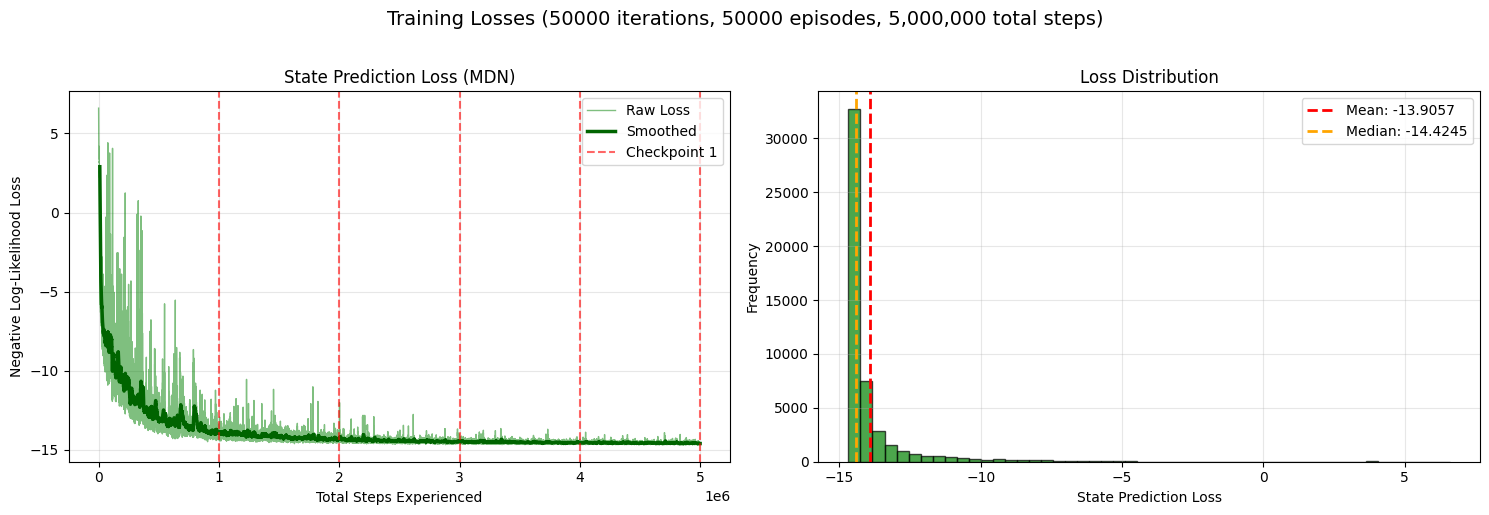


Training Statistics:
  Total iterations: 50000
  Total episodes: 50000
  Steps per batch: 100
  Total steps: 5,000,000
  Checkpoints saved at steps: [1000000, 2000000, 3000000, 4000000, 5000000]

Final Loss:
  State Loss: -14.6338

Loss Statistics:
  Mean: -13.9057
  Median: -14.4245
  Std Dev: 1.5741
  Min: -14.6843
  Max: 6.5998

Improvement:
  Loss improvement: 603.7% (from 2.8981 to -14.5978)

Training Complete!
Total training iterations: 50000
Total steps experienced: 5000000
Total episodes experienced: 50000
Avg steps per episode: 100.0


In [18]:
# Create environment and model
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt
import torch
import os

# Create trained_models directory if it doesn't exist
os.makedirs('trained_models', exist_ok=True)

hidden_dim = 256
training_episodes = 5000000

env = gym.make('CartPole-v1')
env.unwrapped.tau = 0.01
env.reset() 
model = MDRNN(state_dim=4, action_dim=2, hidden_dim=hidden_dim, n_gaussian=5)

# Train the model
train_mdrnn(env, model, total_steps=training_episodes)



## Plot predictions vs reality

Found 5 checkpoints in ../trained_models:
  [1] mdrnn_1000000_steps.pt (1000000 steps)
  [2] mdrnn_2000000_steps.pt (2000000 steps)
  [3] mdrnn_3000000_steps.pt (3000000 steps)
  [4] mdrnn_4000000_steps.pt (4000000 steps)
  [5] mdrnn_5000000_steps.pt (5000000 steps)
Loading checkpoint 5/5: mdrnn_5000000_steps.pt
✓ Successfully loaded model from ../trained_models\mdrnn_5000000_steps.pt
  Steps experienced: 5000000
  Episodes experienced: 50000
  Training iteration: 50000
  Final state loss: -14.6338
Model uses action_dim=2 (one-hot encoding: True)


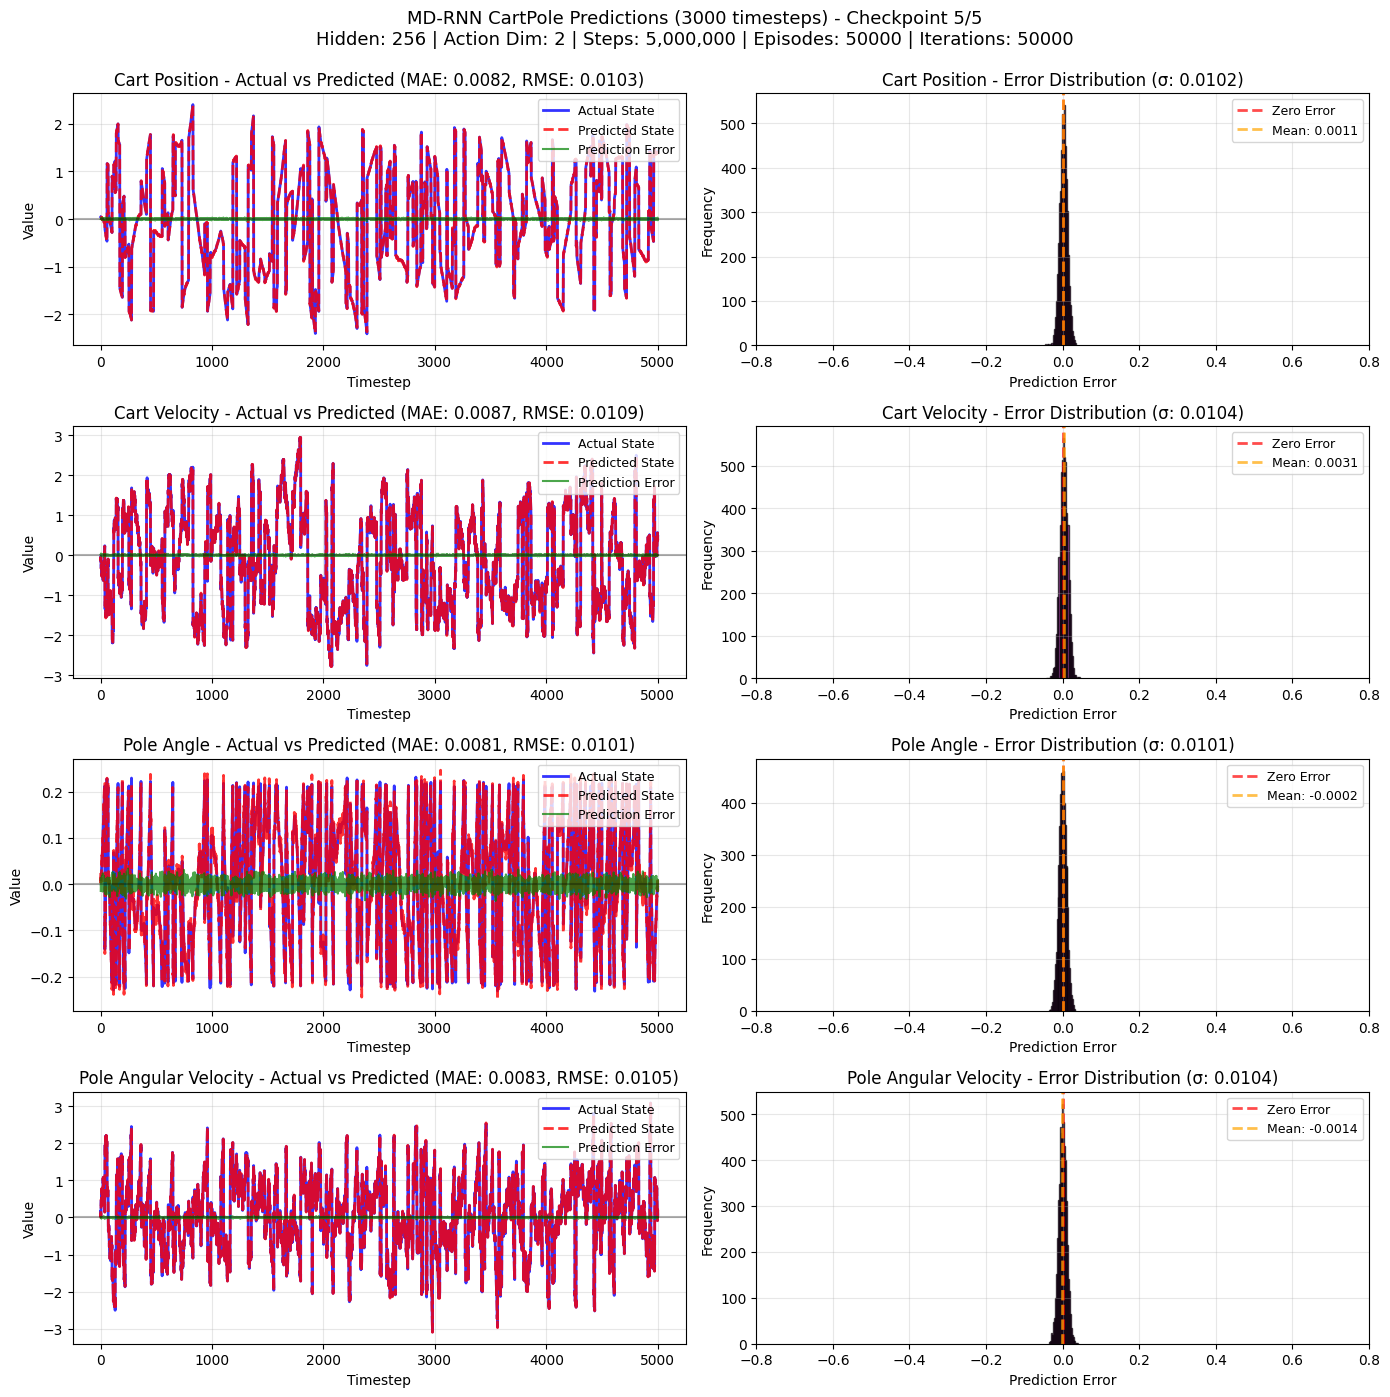


Prediction Error Summary:
Cart Position             | MAE:   0.0082 | RMSE:   0.0103 | Mean:   0.0011 | Std:   0.0102
Cart Velocity             | MAE:   0.0087 | RMSE:   0.0109 | Mean:   0.0031 | Std:   0.0104
Pole Angle                | MAE:   0.0081 | RMSE:   0.0101 | Mean:  -0.0002 | Std:   0.0101
Pole Angular Velocity     | MAE:   0.0083 | RMSE:   0.0105 | Mean:  -0.0014 | Std:   0.0104


In [19]:
import numpy as np
import torch
import gymnasium as gym
import matplotlib.pyplot as plt

# 1. List available checkpoints first
available_checkpoints = list_available_checkpoints('../trained_models')

# 2. Load by checkpoint number
checkpoint_num = 5
model, info = load_model(checkpoint=checkpoint_num)

# Extract info for plot title (handle both old and new formats)
hidden_dim = info['hidden_dim']
action_dim = info['action_dim']  # Add this to verify one-hot encoding
training_steps = info.get('total_steps_experienced', 'N/A')
training_episodes = info.get('total_episodes_experienced', 'N/A')
training_iteration = info.get('training_iteration', 'N/A')
total_checkpoints = len(available_checkpoints)

print(f"Model uses action_dim={action_dim} (one-hot encoding: {action_dim > 1})")

# Test prediction over 3000 timesteps
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device)
model.eval()

# Initialize model hidden state
hidden = model.init_hidden(1, device)

# Collect actual trajectory
env = gym.make('CartPole-v1')
env.unwrapped.tau = 0.01
state, _ = env.reset()  # Initialize once
actual_states = []
predicted_states = []
actions_taken = []

# Randomization ranges
angle_range = 0.18
angular_vel_range = 2.0
pos_range = 2.0
vel_range = 2.0

def reset_with_randomization():
        """Reset environment with randomized initial state."""
        env.unwrapped.tau = 0.01
        state, _ = env.reset()
        
        # Add randomness to initial state
        state[0] = np.random.uniform(-pos_range, pos_range)          
        state[1] = np.random.uniform(-vel_range, vel_range)         
        state[2] = np.random.uniform(-angle_range, angle_range)       
        state[3] = np.random.uniform(-angular_vel_range, angular_vel_range)
        
        # Update the environment's internal state
        env.unwrapped.state = state
        return state

# Helper function to convert action to one-hot
def action_to_onehot(action, n_actions):
    """Convert discrete action to one-hot encoding."""
    onehot = np.zeros(n_actions, dtype=np.float32)
    onehot[action] = 1.0
    return onehot

n_actions = env.action_space.n

print(f"Collecting 3000-step trajectory and predictions...")

for step in range(5000):
    # Choose action (random for this test)
    action = env.action_space.sample()
    actions_taken.append(action)
    
    # Get model prediction
    state_tensor = torch.FloatTensor(state).unsqueeze(0).unsqueeze(0).to(device)
    
    # Convert action to one-hot encoding
    action_onehot = action_to_onehot(action, n_actions)
    action_tensor = torch.FloatTensor(action_onehot).unsqueeze(0).unsqueeze(0).to(device)
    
    with torch.no_grad():
        outputs = model(state_tensor, action_tensor, hidden)
        hidden = outputs['hidden']  # Update hidden state
        
        # Sample prediction from mixture
        predicted_next_state = model.sample_prediction(
            outputs['pi'][0, 0], 
            outputs['mu'][0, 0], 
            outputs['sigma'][0, 0]
        )
        predicted_states.append(predicted_next_state.cpu().numpy())
    
    # Take actual step in environment
    next_state, reward, terminated, truncated, _ = env.step(action)
    
    # Store next state for comparison
    actual_states.append(next_state.copy())
    done = terminated or truncated
    
    state = next_state
    if done:
        env.unwrapped.tau = 0.01
        state, _ = env.reset()
        # Reset model hidden state when episode resets
        hidden = model.init_hidden(1, device)
        # Reset the state to the new initial state
        state = reset_with_randomization()
        # Reset hidden state for this episode
        hidden = model.init_hidden(1, device)

# Convert to numpy arrays
actual_states = np.array(actual_states)
predicted_states = np.array(predicted_states)

predictions = predicted_states
actual_next = actual_states
prediction_errors = actual_next - predictions

# Calculate error metrics
mae = np.mean(np.abs(prediction_errors), axis=0)
rmse = np.sqrt(np.mean(prediction_errors**2, axis=0))

# Create plots
state_names = ['Cart Position', 'Cart Velocity', 'Pole Angle', 'Pole Angular Velocity']

fig, axes = plt.subplots(4, 2, figsize=(14, 14))

# Build title with available information
title_lines = [f'MD-RNN CartPole Predictions (3000 timesteps) - Checkpoint {checkpoint_num}/{total_checkpoints}']
title_parts = [f'Hidden: {hidden_dim}', f'Action Dim: {action_dim}']

if training_steps != 'N/A':
    title_parts.append(f'Steps: {training_steps:,}')
if training_episodes != 'N/A':
    title_parts.append(f'Episodes: {training_episodes}')
if training_iteration != 'N/A':
    title_parts.append(f'Iterations: {training_iteration}')

title_lines.append(' | '.join(title_parts))

fig.suptitle('\n'.join(title_lines), fontsize=13, y=0.995)

# X-axis: timesteps
x_axis = np.arange(1, len(predictions) + 1)

for i in range(4):
    # Plot 1: Actual vs Predicted states WITH prediction error line
    axes[i, 0].plot(x_axis, actual_next[:, i], 'b-', 
                   label='Actual State', linewidth=2, alpha=0.8)
    axes[i, 0].plot(x_axis, predictions[:, i], 'r--', 
                   label='Predicted State', linewidth=2, alpha=0.8)
    axes[i, 0].plot(x_axis, prediction_errors[:, i], 'g-', 
                   label='Prediction Error', linewidth=1.5, alpha=0.7)
    
    # Add error metrics to title
    axes[i, 0].set_title(f'{state_names[i]} - Actual vs Predicted (MAE: {mae[i]:.4f}, RMSE: {rmse[i]:.4f})')
    axes[i, 0].set_xlabel('Timestep')
    axes[i, 0].set_ylabel('Value')
    axes[i, 0].grid(True, alpha=0.3)
    axes[i, 0].axhline(y=0, color='k', linestyle='-', alpha=0.3)
    axes[i, 0].legend(loc='upper right', fontsize=9)
    
    # Plot 2: Error distribution
    axes[i, 1].hist(prediction_errors[:, i], bins=30, alpha=0.7, 
                   color='purple', edgecolor='black')
    axes[i, 1].axvline(x=0, color='red', linestyle='--', alpha=0.7, linewidth=2, label='Zero Error')
    
    # Add mean and std to distribution plot
    mean_error = np.mean(prediction_errors[:, i])
    std_error = np.std(prediction_errors[:, i])
    axes[i, 1].axvline(x=mean_error, color='orange', linestyle='--', alpha=0.7, 
                      linewidth=2, label=f'Mean: {mean_error:.4f}')
    
    axes[i, 1].set_title(f'{state_names[i]} - Error Distribution (σ: {std_error:.4f})')
    axes[i, 1].set_xlabel('Prediction Error')
    axes[i, 1].set_ylabel('Frequency')
    axes[i, 1].grid(True, alpha=0.3)
    axes[i, 1].legend(loc='upper right', fontsize=9)
    # add xlims
    axes[i, 1].set_xlim([-0.8, 0.8])

plt.tight_layout()
plt.show()

# Print summary statistics
print("\n" + "="*60)
print("Prediction Error Summary:")
print("="*60)
for i, name in enumerate(state_names):
    print(f"{name:25s} | MAE: {mae[i]:8.4f} | RMSE: {rmse[i]:8.4f} | Mean: {np.mean(prediction_errors[:, i]):8.4f} | Std: {np.std(prediction_errors[:, i]):8.4f}")
print("="*60)

## Old code

In [ ]:
class MDRNN(nn.Module):
    """Mixture Density RNN for CartPole world model.
    
    Predicts next state distribution as a Gaussian Mixture Model.
    State: [x, x_dot, theta, theta_dot] (4D)
    Action: discrete (0 or 1) for left/right
    """
    
    def __init__(self, state_dim=4, action_dim=1, hidden_dim=256, 
                 n_gaussian=5, n_layers=1):
        super().__init__()
        
        self.state_dim = state_dim
        self.action_dim = action_dim
        self.hidden_dim = hidden_dim
        self.n_gaussian = n_gaussian
        self.n_layers = n_layers
        
        # LSTM that processes state+action sequences
        self.lstm = nn.LSTM(
            state_dim + action_dim, 
            hidden_dim, 
            n_layers, 
            batch_first=True
        )
        
        # Simplified output heads - using diagonal covariance for simplicity
        self.pi_head = nn.Linear(hidden_dim, n_gaussian)
        self.mu_head = nn.Linear(hidden_dim, n_gaussian * state_dim)
        self.sigma_head = nn.Linear(hidden_dim, n_gaussian * state_dim)
        
        # Optional: predict reward
        self.reward_head = nn.Linear(hidden_dim, 1)
        
        # Optional: predict done flag
        self.done_head = nn.Linear(hidden_dim, 1)
        
    def forward(self, states, actions, hidden=None):
        """
        Args:
            states: (batch, seq_len, state_dim)
            actions: (batch, seq_len, action_dim)
            hidden: tuple of (h, c) for LSTM hidden states
        
        Returns:
            pi: mixture weights (batch, seq_len, n_gaussian)
            mu: means (batch, seq_len, n_gaussian, state_dim)
            sigma: std devs (batch, seq_len, n_gaussian, state_dim)
            hidden: updated LSTM hidden state
        """
        batch_size, seq_len = states.shape[:2]
        
        # Concatenate state and action
        x = torch.cat([states, actions], dim=-1)
        
        # Process through LSTM
        lstm_out, hidden = self.lstm(x, hidden)
        
        # Compute mixture parameters
        pi = self.pi_head(lstm_out).view(batch_size, seq_len, self.n_gaussian)
        mu = self.mu_head(lstm_out).view(batch_size, seq_len, self.n_gaussian, self.state_dim)
        sigma = self.sigma_head(lstm_out).view(batch_size, seq_len, self.n_gaussian, self.state_dim)
        
        # Apply activations
        pi = F.softmax(pi, dim=-1)  # Normalize mixture weights
        sigma = F.softplus(sigma) + 1e-6  # Ensure positive std dev
        
        # Optional outputs
        reward = self.reward_head(lstm_out)
        done_logit = self.done_head(lstm_out)
        
        return {
            'pi': pi,
            'mu': mu, 
            'sigma': sigma,
            'reward': reward,
            'done_logit': done_logit,
            'hidden': hidden
        }
    
    def sample_prediction(self, pi, mu, sigma, temperature=1.0):
        """Sample next state from the mixture distribution.
        
        Args:
            pi: (n_gaussian,)
            mu: (n_gaussian, state_dim)
            sigma: (n_gaussian, state_dim)
            temperature: sampling temperature
        
        Returns:
            next_state: (state_dim,)
        """
        # Sample mixture component
        k = torch.multinomial(pi, 1).item()
        
        # Sample from the selected gaussian
        mean = mu[k]
        std = sigma[k] * temperature
        next_state = torch.normal(mean, std)
        
        return next_state
    
    def init_hidden(self, batch_size, device):
        """Initialize LSTM hidden state."""
        h = torch.zeros(self.n_layers, batch_size, self.hidden_dim, device=device)
        c = torch.zeros(self.n_layers, batch_size, self.hidden_dim, device=device)
        return (h, c)


def mdn_loss(pi, mu, sigma, target, reduce=True):
    """Negative log-likelihood loss for mixture density network.
    
    Args:
        pi: (batch, seq_len, n_gaussian)
        mu: (batch, seq_len, n_gaussian, state_dim)
        sigma: (batch, seq_len, n_gaussian, state_dim)
        target: (batch, seq_len, state_dim) - actual next states
    
    Returns:
        loss: scalar or (batch, seq_len) depending on reduce
    """
    # Expand target for broadcasting
    target = target.unsqueeze(2)  # (batch, seq_len, 1, state_dim)
    
    # Compute gaussian probabilities
    variance = sigma ** 2
    log_prob = -0.5 * ((target - mu) ** 2) / variance
    log_prob = log_prob - 0.5 * torch.log(2 * math.pi * variance)
    
    # Sum over state dimensions
    log_prob = log_prob.sum(dim=-1)  # (batch, seq_len, n_gaussian)
    
    # Weight by mixture coefficients
    weighted_log_prob = log_prob + torch.log(pi + 1e-8)
    
    # LogSumExp for numerical stability
    max_log_prob = weighted_log_prob.max(dim=-1, keepdim=True)[0]
    log_sum_exp = max_log_prob + torch.log(torch.exp(weighted_log_prob - max_log_prob).sum(dim=-1, keepdim=True))
    
    nll = -log_sum_exp.squeeze(-1)
    
    if reduce:
        return nll.mean()
    return nll

def train_mdrnn(env, mdrnn, total_steps=100000, lr=1e-3, steps_per_batch=100, 
                save_dir='../trained_models'):
    """Train the MD-RNN on CartPole environment.
    
    Args:
        total_steps: Total environment steps to train on
        lr: Learning rate
        steps_per_batch: Number of steps per training iteration
        save_dir: Directory to save model checkpoints
    """
    
    import os
    import numpy as np
    
    os.makedirs(save_dir, exist_ok=True)
    
    optimizer = torch.optim.Adam(mdrnn.parameters(), lr=lr)
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    mdrnn = mdrnn.to(device)
    
    # Calculate checkpoint steps (evenly distributed)
    checkpoint_steps = [total_steps // 5 * i for i in range(1, 6)]
    print(f"Will save models at steps: {checkpoint_steps}")
    print(f"Training with {steps_per_batch} steps per batch")
    print(f"Expected iterations: {total_steps // steps_per_batch}\n")
    
    # Track losses
    total_losses = []
    state_losses = []
    reward_losses = []
    done_losses = []
    
    total_steps_experienced = 0
    total_episodes_experienced = 0
    training_iteration = 0
    checkpoints_saved = 0
    checkpoint_iterations = []
    
    # Initialize environment
    env.unwrapped.tau = 0.01
    state, _ = env.reset()
    
    while total_steps_experienced < total_steps:
        # Collect exactly steps_per_batch data points
        states, actions, next_states, rewards, dones = [], [], [], [], []
        
        # Count episodes in this batch
        episodes_in_batch = 0
        
        # Determine how many steps to collect (don't exceed total_steps)
        steps_to_collect = min(steps_per_batch, total_steps - total_steps_experienced)
        
        for step in range(steps_to_collect):
            # Sample random action
            action = env.action_space.sample()
            
            # Take step in environment
            next_state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated
            
            # Store transition (one data point)
            states.append(state)
            actions.append([action])
            next_states.append(next_state)
            rewards.append(reward)
            dones.append(done)
            
            # Update state
            state = next_state
            
            # Handle episode termination
            if done:
                episodes_in_batch += 1
                env.unwrapped.tau = 0.01
                state, _ = env.reset()
        
        # Update counters
        total_steps_experienced += steps_to_collect
        total_episodes_experienced += episodes_in_batch
        
        # Skip if we collected no data (shouldn't happen, but safety check)
        if len(states) == 0:
            break
        
        # Convert to tensors - shape: (1, seq_len, dim)
        states_t = torch.from_numpy(np.array(states, dtype=np.float32)).unsqueeze(0).to(device)
        actions_t = torch.from_numpy(np.array(actions, dtype=np.float32)).unsqueeze(0).to(device)
        next_states_t = torch.from_numpy(np.array(next_states, dtype=np.float32)).unsqueeze(0).to(device)
        rewards_t = torch.from_numpy(np.array(rewards, dtype=np.float32)).unsqueeze(0).unsqueeze(-1).to(device)
        dones_t = torch.from_numpy(np.array(dones, dtype=np.float32)).unsqueeze(0).unsqueeze(-1).to(device)
        
        # Forward pass
        hidden = mdrnn.init_hidden(1, device)
        outputs = mdrnn(states_t, actions_t, hidden)
        
        # Compute losses
        state_loss = mdn_loss(outputs['pi'], outputs['mu'], outputs['sigma'], next_states_t)
        reward_loss = F.mse_loss(outputs['reward'], rewards_t)
        done_loss = F.binary_cross_entropy_with_logits(outputs['done_logit'], dones_t)
        
        total_loss = state_loss + 0.1 * reward_loss + 0.1 * done_loss
        
        # Store losses
        total_losses.append(total_loss.item())
        state_losses.append(state_loss.item())
        reward_losses.append(reward_loss.item())
        done_losses.append(done_loss.item())
        
        # Backward pass
        optimizer.zero_grad()
        total_loss.backward()
        torch.nn.utils.clip_grad_norm_(mdrnn.parameters(), 10.0)
        optimizer.step()
        
        training_iteration += 1
        
        # Save model at checkpoints (based on steps)
        if checkpoints_saved < len(checkpoint_steps) and total_steps_experienced >= checkpoint_steps[checkpoints_saved]:
            checkpoint_path = os.path.join(save_dir, f'mdrnn_{total_steps_experienced}_steps.pt')
            torch.save({
                'state_dim': mdrnn.state_dim,
                'action_dim': mdrnn.action_dim,
                'hidden_dim': mdrnn.hidden_dim,
                'n_gaussian': mdrnn.n_gaussian,
                'n_layers': mdrnn.n_layers,
                'training_iteration': training_iteration,
                'total_steps_experienced': total_steps_experienced,
                'total_episodes_experienced': total_episodes_experienced,
                'model_state_dict': mdrnn.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'total_loss': total_loss.item(),
                'state_loss': state_loss.item(),
                'reward_loss': reward_loss.item(),
                'done_loss': done_loss.item(),
            }, checkpoint_path)
            
            checkpoint_iterations.append(training_iteration)
            checkpoints_saved += 1
            print(f"✓ Saved checkpoint {checkpoints_saved}/5 at {total_steps_experienced} steps")
            print(f"  Episodes experienced: {total_episodes_experienced}")
            print(f"  Training iteration: {training_iteration}")
            print(f"  Saved to: {checkpoint_path}\n")
        
        if training_iteration % 50 == 0:
            print(f"Iteration {training_iteration:4d} | Steps: {total_steps_experienced:6d} | "
                  f"Episodes: {total_episodes_experienced:4d} | Loss: {total_loss.item():.4f}")
    
    # Plot training losses with checkpoint markers
    plot_training_losses(total_losses, state_losses, reward_losses, done_losses, 
                         total_episodes=total_episodes_experienced,
                         steps_per_batch=steps_per_batch,
                         checkpoint_iterations=checkpoint_iterations)
    
    print(f"\n{'='*60}")
    print(f"Training Complete!")
    print(f"Total training iterations: {training_iteration}")
    print(f"Total steps experienced: {total_steps_experienced}")
    print(f"Total episodes experienced: {total_episodes_experienced}")
    print(f"Avg steps per episode: {total_steps_experienced / total_episodes_experienced:.1f}")
    print(f"{'='*60}")

def load_model(save_dir='../trained_models', checkpoint=None, model_path=None):
    """Load a saved MDRNN model.
    
    Args:
        save_dir: Directory where models are saved (default: '../trained_models')
        checkpoint: Checkpoint number (1-5) to load, or None if using model_path
        model_path: Direct path to model file (overrides save_dir and checkpoint)
        
    Returns:
        loaded_model: MDRNN model with loaded weights
        checkpoint_data: Dictionary containing all checkpoint information
        
    Examples:
        # Load by checkpoint number
        model, info = load_model(checkpoint=3)
        
        # Load by checkpoint number from specific directory
        model, info = load_model(save_dir='my_models', checkpoint=2)
        
        # Load by direct path
        model, info = load_model(model_path='trained_models/mdrnn_60000_steps.pt')
    """
    import os
    import glob
    
    # Determine the file path
    if model_path is not None:
        # Direct path provided
        file_path = model_path
    elif checkpoint is not None:
        # Find file by checkpoint number
        if not 1 <= checkpoint <= 5:
            raise ValueError(f"Checkpoint must be between 1 and 5, got {checkpoint}")
        
        # Find all model files in the directory (try steps first, then episodes for backwards compatibility)
        pattern_steps = os.path.join(save_dir, 'mdrnn_*_steps.pt')
        pattern_episodes = os.path.join(save_dir, 'mdrnn_*_episodes.pt')
        
        model_files = sorted(glob.glob(pattern_steps))
        if not model_files:
            # Fallback to old episode-based naming
            model_files = sorted(glob.glob(pattern_episodes))
        
        if not model_files:
            raise FileNotFoundError(f"No model files found in {save_dir}")
        
        if len(model_files) < checkpoint:
            raise FileNotFoundError(
                f"Checkpoint {checkpoint} not found. Only {len(model_files)} checkpoints available: {model_files}"
            )
        
        # Get the checkpoint file (1-indexed)
        file_path = model_files[checkpoint - 1]
        print(f"Loading checkpoint {checkpoint}/{len(model_files)}: {os.path.basename(file_path)}")
    else:
        raise ValueError("Must provide either 'checkpoint' (1-5) or 'model_path'")
    
    # Load the checkpoint
    checkpoint_data = torch.load(file_path)
    
    # Create model with saved parameters
    loaded_model = MDRNN(
        state_dim=checkpoint_data['state_dim'], 
        action_dim=checkpoint_data['action_dim'], 
        hidden_dim=checkpoint_data['hidden_dim'], 
        n_gaussian=checkpoint_data['n_gaussian'],
        n_layers=checkpoint_data['n_layers']
    )
    
    # Load the state dict
    loaded_model.load_state_dict(checkpoint_data['model_state_dict'])
    
    # Print info about loaded model
    print(f"✓ Successfully loaded model from {file_path}")
    
    # Handle both old (episodes) and new (steps) checkpoint formats
    if 'total_steps_experienced' in checkpoint_data:
        print(f"  Steps experienced: {checkpoint_data['total_steps_experienced']}")
    if 'total_episodes_experienced' in checkpoint_data:
        print(f"  Episodes experienced: {checkpoint_data['total_episodes_experienced']}")
    
    print(f"  Training iteration: {checkpoint_data['training_iteration']}")
    print(f"  Final losses - Total: {checkpoint_data['total_loss']:.4f}, State: {checkpoint_data['state_loss']:.4f}")
    
    return loaded_model, checkpoint_data


def list_available_checkpoints(save_dir='../trained_models'):
    """List all available model checkpoints in a directory.
    
    Args:
        save_dir: Directory to search for model files
        
    Returns:
        List of checkpoint file paths
    """
    import os
    import glob
    
    # Try both naming conventions
    pattern_steps = os.path.join(save_dir, 'mdrnn_*_steps.pt')
    pattern_episodes = os.path.join(save_dir, 'mdrnn_*_episodes.pt')
    
    model_files = sorted(glob.glob(pattern_steps))
    if not model_files:
        model_files = sorted(glob.glob(pattern_episodes))
    
    if not model_files:
        print(f"No model files found in {save_dir}")
        return []
    
    print(f"Found {len(model_files)} checkpoints in {save_dir}:")
    for i, file_path in enumerate(model_files, 1):
        # Extract count from filename
        filename = os.path.basename(file_path)
        # Handle both "mdrnn_20000_steps.pt" and "mdrnn_1000_episodes.pt"
        parts = filename.split('_')
        count = parts[1]
        unit = parts[2].replace('.pt', '')  # 'steps' or 'episodes'
        print(f"  [{i}] {filename} ({count} {unit})")
    
    return model_files

def plot_training_losses(total_losses, state_losses, reward_losses, done_losses, 
                         total_episodes=None, steps_per_batch=None, checkpoint_iterations=None):
    """Plot training losses over total steps experienced.
    
    Args:
        total_losses, state_losses, reward_losses, done_losses: Loss arrays
        total_episodes: Total episodes experienced (optional)
        steps_per_batch: Steps per training iteration (optional)
        checkpoint_iterations: List of iteration numbers where checkpoints were saved (optional)
    """
    
    fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 10))
    
    # X-axis is now total steps, not iterations
    if steps_per_batch is not None:
        # Each iteration corresponds to steps_per_batch steps
        # X values: steps_per_batch, 2*steps_per_batch, 3*steps_per_batch, ...
        x_values = [(i + 1) * steps_per_batch for i in range(len(total_losses))]
        total_steps = len(total_losses) * steps_per_batch
        x_label = 'Total Steps Experienced'
    else:
        # Fallback to iterations if steps_per_batch not provided
        x_values = range(len(total_losses))
        total_steps = len(total_losses)
        x_label = 'Training Iteration'
    
    # Add informative title
    title = f'Training Losses ({len(total_losses)} iterations'
    if total_episodes is not None:
        title += f', {total_episodes} episodes'
    if steps_per_batch is not None:
        title += f', {total_steps:,} total steps'
    title += ')'
    fig.suptitle(title, fontsize=14, y=0.995)
    
    # Helper function to add checkpoint lines
    def add_checkpoint_lines(ax):
        if checkpoint_iterations is not None and steps_per_batch is not None:
            for i, checkpoint_iter in enumerate(checkpoint_iterations, 1):
                # Convert iteration to steps
                checkpoint_step = checkpoint_iter * steps_per_batch
                ax.axvline(x=checkpoint_step, color='red', linestyle='--', 
                          alpha=0.6, linewidth=1.5, label=f'Checkpoint {i}' if ax == ax1 else '')
    
    # Total loss
    ax1.plot(x_values, total_losses, 'b-', alpha=0.7, label='Loss')
    ax1.set_title('Total Loss')
    ax1.set_xlabel(x_label)
    ax1.set_ylabel('Loss')
    ax1.grid(True, alpha=0.3)
    
    # Add smoothed line for total loss
    if len(total_losses) > 50:
        window = min(100, len(total_losses) // 10)
        smoothed = np.convolve(total_losses, np.ones(window)/window, mode='valid')
        smoothed_x = x_values[window-1:]
        ax1.plot(smoothed_x, smoothed, 'r-', linewidth=2, label='Smoothed')
    
    add_checkpoint_lines(ax1)
    ax1.legend()
    
    # State loss (main component)
    ax2.plot(x_values, state_losses, 'g-', alpha=0.7)
    ax2.set_title('State Prediction Loss (MDN)')
    ax2.set_xlabel(x_label)
    ax2.set_ylabel('Loss')
    ax2.grid(True, alpha=0.3)
    add_checkpoint_lines(ax2)
    
    # Reward loss
    ax3.plot(x_values, reward_losses, 'orange', alpha=0.7)
    ax3.set_title('Reward Prediction Loss')
    ax3.set_xlabel(x_label)
    ax3.set_ylabel('MSE Loss')
    ax3.grid(True, alpha=0.3)
    add_checkpoint_lines(ax3)
    
    # Done loss
    ax4.plot(x_values, done_losses, 'purple', alpha=0.7)
    ax4.set_title('Done Prediction Loss')
    ax4.set_xlabel(x_label)
    ax4.set_ylabel('BCE Loss')
    ax4.grid(True, alpha=0.3)
    add_checkpoint_lines(ax4)
    
    plt.tight_layout()
    plt.show()
    
    # Print final statistics
    print(f"\n{'='*60}")
    print(f"Training Statistics:")
    print(f"  Total iterations: {len(total_losses)}")
    if total_episodes is not None:
        print(f"  Total episodes: {total_episodes}")
    if steps_per_batch is not None:
        print(f"  Steps per batch: {steps_per_batch}")
        print(f"  Total steps: {total_steps:,}")
    if checkpoint_iterations is not None and steps_per_batch is not None:
        checkpoint_steps = [it * steps_per_batch for it in checkpoint_iterations]
        print(f"  Checkpoints saved at steps: {checkpoint_steps}")
    print(f"\nFinal Losses:")
    print(f"  Total Loss: {total_losses[-1]:.4f}")
    print(f"  State Loss: {state_losses[-1]:.4f}")
    print(f"  Reward Loss: {reward_losses[-1]:.4f}")
    print(f"  Done Loss: {done_losses[-1]:.4f}")
    
    # Show improvement
    if len(total_losses) > 100:
        initial_avg = np.mean(total_losses[:100])
        final_avg = np.mean(total_losses[-100:])
        improvement = ((initial_avg - final_avg) / initial_avg) * 100
        print(f"\nImprovement:")
        print(f"  Loss improvement: {improvement:.1f}% (from {initial_avg:.4f} to {final_avg:.4f})")
    print(f"{'='*60}")



In [ ]:
import numpy as np
import torch
import gymnasium as gym
import matplotlib.pyplot as plt

# 1. List available checkpoints first
available_checkpoints = list_available_checkpoints('../trained_models')

# 2. Load by checkpoint number
checkpoint_num = 3
model, info = load_model(checkpoint=checkpoint_num)

# Extract info for plot title (handle both old and new formats)
hidden_dim = info['hidden_dim']
training_steps = info.get('total_steps_experienced', 'N/A')
training_episodes = info.get('total_episodes_experienced', 'N/A')
training_iteration = info.get('training_iteration', 'N/A')
total_checkpoints = len(available_checkpoints)

# Test prediction over 200 timesteps
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device)
model.eval()

# Initialize model hidden state
hidden = model.init_hidden(1, device)

# Collect actual trajectory
env = gym.make('CartPole-v1')
env.unwrapped.tau = 0.01
state, _ = env.reset()  # Initialize once
actual_states = []
predicted_states = []
actions_taken = []

print("Collecting 200-step trajectory and predictions...")

for step in range(3000):
    # Choose action (random for this test)
    action = env.action_space.sample()
    actions_taken.append(action)
    
    # Get model prediction
    state_tensor = torch.FloatTensor(state).unsqueeze(0).unsqueeze(0).to(device)
    action_tensor = torch.FloatTensor([[action]]).unsqueeze(0).to(device)
    
    with torch.no_grad():
        outputs = model(state_tensor, action_tensor, hidden)
        hidden = outputs['hidden']  # Update hidden state
        
        # Sample prediction from mixture
        predicted_next_state = model.sample_prediction(
            outputs['pi'][0, 0], 
            outputs['mu'][0, 0], 
            outputs['sigma'][0, 0]
        )
        predicted_states.append(predicted_next_state.cpu().numpy())
    
    # Take actual step in environment
    next_state, reward, terminated, truncated, _ = env.step(action)
    
    # Store next state for comparison
    actual_states.append(next_state.copy())
    done = terminated or truncated
    
    state = next_state
    if done:
        env.unwrapped.tau = 0.01
        state, _ = env.reset()
        # Reset model hidden state when episode resets
        hidden = model.init_hidden(1, device)

# Convert to numpy arrays
actual_states = np.array(actual_states)
predicted_states = np.array(predicted_states)

predictions = predicted_states
actual_next = actual_states
prediction_errors = actual_next - predictions

# Calculate error metrics
mae = np.mean(np.abs(prediction_errors), axis=0)
rmse = np.sqrt(np.mean(prediction_errors**2, axis=0))

# Create plots
state_names = ['Cart Position', 'Cart Velocity', 'Pole Angle', 'Pole Angular Velocity']

fig, axes = plt.subplots(4, 2, figsize=(14, 14))

# Build title with available information
title_lines = [f'MD-RNN CartPole Predictions (200 timesteps) - Checkpoint {checkpoint_num}/{total_checkpoints}']
title_parts = [f'Hidden: {hidden_dim}']

if training_steps != 'N/A':
    title_parts.append(f'Steps: {training_steps:,}')
if training_episodes != 'N/A':
    title_parts.append(f'Episodes: {training_episodes}')
if training_iteration != 'N/A':
    title_parts.append(f'Iterations: {training_iteration}')

title_lines.append(' | '.join(title_parts))

fig.suptitle('\n'.join(title_lines), fontsize=13, y=0.995)

# X-axis: timesteps
x_axis = np.arange(1, len(predictions) + 1)

for i in range(4):
    # Plot 1: Actual vs Predicted states WITH prediction error line
    axes[i, 0].plot(x_axis, actual_next[:, i], 'b-', 
                   label='Actual State', linewidth=2, alpha=0.8)
    axes[i, 0].plot(x_axis, predictions[:, i], 'r--', 
                   label='Predicted State', linewidth=2, alpha=0.8)
    axes[i, 0].plot(x_axis, prediction_errors[:, i], 'g-', 
                   label='Prediction Error', linewidth=1.5, alpha=0.7)
    
    # Add error metrics to title
    axes[i, 0].set_title(f'{state_names[i]} - Actual vs Predicted (MAE: {mae[i]:.4f}, RMSE: {rmse[i]:.4f})')
    axes[i, 0].set_xlabel('Timestep')
    axes[i, 0].set_ylabel('Value')
    axes[i, 0].grid(True, alpha=0.3)
    axes[i, 0].axhline(y=0, color='k', linestyle='-', alpha=0.3)
    axes[i, 0].legend(loc='upper right', fontsize=9)
    
    # Plot 2: Error distribution
    axes[i, 1].hist(prediction_errors[:, i], bins=30, alpha=0.7, 
                   color='purple', edgecolor='black')
    axes[i, 1].axvline(x=0, color='red', linestyle='--', alpha=0.7, linewidth=2, label='Zero Error')
    
    # Add mean and std to distribution plot
    mean_error = np.mean(prediction_errors[:, i])
    std_error = np.std(prediction_errors[:, i])
    axes[i, 1].axvline(x=mean_error, color='orange', linestyle='--', alpha=0.7, 
                      linewidth=2, label=f'Mean: {mean_error:.4f}')
    
    axes[i, 1].set_title(f'{state_names[i]} - Error Distribution (σ: {std_error:.4f})')
    axes[i, 1].set_xlabel('Prediction Error')
    axes[i, 1].set_ylabel('Frequency')
    axes[i, 1].grid(True, alpha=0.3)
    axes[i, 1].legend(loc='upper right', fontsize=9)
    # add xlims
    axes[i, 1].set_xlim([-0.8, 0.8])


plt.tight_layout()
plt.show()

# Print summary statistics
print("\n" + "="*60)
print("Prediction Error Summary:")
print("="*60)
for i, name in enumerate(state_names):
    print(f"{name:25s} | MAE: {mae[i]:8.4f} | RMSE: {rmse[i]:8.4f} | Mean: {np.mean(prediction_errors[:, i]):8.4f} | Std: {np.std(prediction_errors[:, i]):8.4f}")
print("="*60)